In [ ]:
import numpy as np

def perceptron_predict(w, b, x):
    count = 0
    for i in range(len(w)):
        count+= w[i] * x[i]
    count+= b
    if (count >= 0):
        return 1
    else:
        return -1


def perceptron_train(X, y, max_runs=1000, step=1.0):
    N, d = X.shape
    w = np.zeros(d)
    b = 0
    updates = 0 # for part d

    for run in range(max_runs):
        errors = 0

        # shuffle indices randomly each run
        idx = np.random.permutation(N)
        for i in idx:
            if y[i] * perceptron_predict(w, b, X[i]) <= 0:  # misclassified
                w += step * y[i] * X[i]
                b += step * y[i]
                updates += 1
                errors += 1

        if errors == 0:  # converged
            break

    return w, b, updates




In [74]:
from sklearn import datasets

# Load
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Restrict to classes 0 and 1
mask = y < 2
X = X[mask]
y = y[mask]

# Keep ONLY features 1 and 3 (sepal width, petal width)
X = X[:, [1, 3]]

# Recode labels: 0 → -1 , 1 → +1
y = np.where(y == 0, -1, +1)


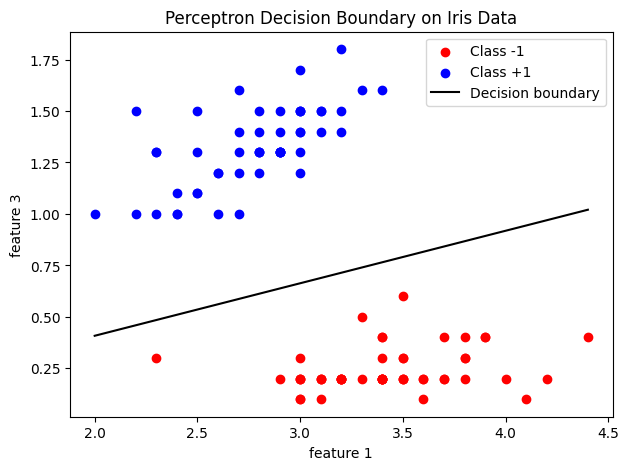

In [77]:
import matplotlib.pyplot as plt

# Train
w, b, _ = perceptron_train(X, y)

# Plot data
plt.figure(figsize=(7,5))
plt.scatter(X[y==-1,0], X[y==-1,1], color='red', label='Class -1')
plt.scatter(X[y==+1,0], X[y==+1,1], color='blue', label='Class +1')

# Decision boundary: w1*x1 + w2*x2 + b = 0 ⇒ x2 = -(w1*x1 + b)/w2
x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
y_vals = -(w[0]*x_vals + b) / w[1]

plt.plot(x_vals, y_vals, color='black', label='Decision boundary')
plt.xlabel("feature 1")
plt.ylabel("feature 3")
plt.legend()
plt.title("Perceptron Decision Boundary on Iris Data")
plt.show()


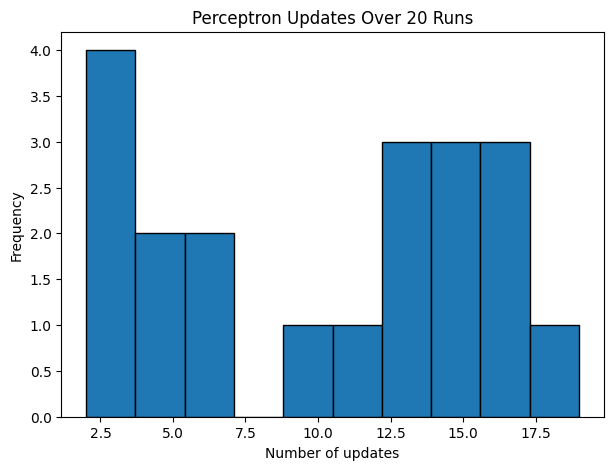

Updates each run:
[10, 4, 15, 15, 19, 2, 2, 13, 13, 11, 2, 4, 2, 17, 15, 13, 6, 17, 17, 6]


In [76]:
updates_list = []

for _ in range(20):
    _, _, updates = perceptron_train(X, y)
    updates_list.append(updates)

# Histogram
plt.figure(figsize=(7,5))
plt.hist(updates_list, bins=10, edgecolor='black')
plt.xlabel("Number of updates")
plt.ylabel("Frequency")
plt.title("Perceptron Updates Over 20 Runs")
plt.show()

print("Updates each run:")
print(updates_list)


In [ ]:
X = X[:, [0, 2]]